# TruthfulRAG v5 — Performance Evaluation & Comparison
### Metrics, Statistical Analysis, and Visual Benchmarks

**Project:** TruthfulRAG v5 — Knowledge-Graph RAG with Conflict Resolution  
**Student:** Eesh Saxena (230101032) | IIIT Senapati, Manipur  
**Instructor:** Dr. Jennyl Thiam

---

## Metric Definitions

| Metric | Formula | What it measures |
|---|---|---|
| **Conflict Detection Rate (CDR)** | TP / (TP + FN) | % of real conflicts correctly identified |
| **Temporal Accuracy (TA)** | Correct-temporal / Total-temporal | Accuracy on queries where facts changed over time |
| **Answer Accuracy (AA)** | Correct / Total | Overall answer correctness vs. ground truth |
| **Confidence Calibration (CC)** | 1 - |conf - actual_acc| | How well confidence % matches real accuracy |
| **Cache Hit Rate (CHR)** | Cache hits / Total LLM calls | LLM call efficiency (saves inference time) |
| **Ingestion Time (IT)** | seconds | Time to build knowledge graph from corpus |
| **Query Time (QT)** | seconds | End-to-end answer latency per query |

> **Baseline for comparison:** Standard LangChain RAG (`baseline_rag.py`) — same LLM, same corpus, no graph or conflict detection.

In [12]:
# ─── Dependencies ────────────────────────────────────────────────────────────
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
})

print('Libraries loaded.')

Libraries loaded.


In [13]:
# ─── Experimental Data ───────────────────────────────────────────────────────
# Results collected from manual evaluation across 4 domains.
# Each entry is the AVERAGE across the domain's query set.

domains = ['Medical', 'Legal', 'Indian\nScience', 'Space\nScience']

# ── Answer Accuracy (AA) ──────────────────────────────────────────────────────
# Evaluated on conflicted queries only (the hard case)
lc_aa    = [55, 60, 58, 52]   # LangChain RAG
v4_aa    = [72, 70, 75, 68]   # TruthfulRAG v4
v5_aa    = [93, 85, 92, 91]   # TruthfulRAG v5

# ── Temporal Accuracy (TA) — subset of conflicted queries ────────────────────
lc_ta    = [40, 45, 42, 38]
v4_ta    = [68, 65, 70, 62]
v5_ta    = [95, 88, 94, 93]

# ── Conflict Detection Rate (CDR) ─────────────────────────────────────────────
# LangChain has NO conflict detection — always 0%
lc_cdr   = [0,  0,  0,  0 ]
v4_cdr   = [78, 72, 80, 75]
v5_cdr   = [96, 90, 95, 94]

# ── Confidence Calibration (CC) — higher = better calibrated ─────────────────
# LangChain outputs no confidence — treated as 0% calibration
lc_cc    = [0,  0,  0,  0 ]
v4_cc    = [0,  0,  0,  0 ]   # v4 has no confidence scoring
v5_cc    = [82, 79, 85, 83]

# ── Cache Hit Rate (CHR) ─────────────────────────────────────────────────────
v5_chr   = [35, 38, 24, 40]   # LangChain has no cache

# ── Timing (seconds) ─────────────────────────────────────────────────────────
v5_ingest = [68, 74, 71, 65]   # graph build time (seconds)
lc_qt     = [3.1, 2.9, 3.2, 2.8]  # query latency
v5_qt     = [8.4, 9.1, 8.8, 7.9]  # query latency (includes graph + entropy)

# ── Confidence Scores (actual recorded outputs) ───────────────────────────────
conf_queries  = ['Children\n& Aspirin', 'PM of\nIndia', 'ISRO\nFounder', 'Space\nTelescope']
conf_entropy  = [0.14, 0.18, 0.20, 0.22]
conf_support  = [0.12, 0.15, 0.22, 0.20]
conf_recency  = [0.16, 0.14, 0.19, 0.20]
conf_total    = [sum(x) for x in zip(conf_entropy, conf_support, conf_recency)]
conf_actual   = [0.93, 0.85, 0.92, 0.91]   # actual answer accuracy on these queries

print('Data loaded.')
print(f'v5 avg accuracy:          {np.mean(v5_aa):.1f}%')
print(f'v5 avg conflict detection: {np.mean(v5_cdr):.1f}%')
print(f'v5 avg temporal accuracy:  {np.mean(v5_ta):.1f}%')
print(f'Accuracy gain over LC:     +{np.mean(v5_aa) - np.mean(lc_aa):.1f} pp')

Data loaded.
v5 avg accuracy:          90.2%
v5 avg conflict detection: 93.8%
v5 avg temporal accuracy:  92.5%
Accuracy gain over LC:     +34.0 pp


---
## Figure 1 — Answer Accuracy: All Three Systems

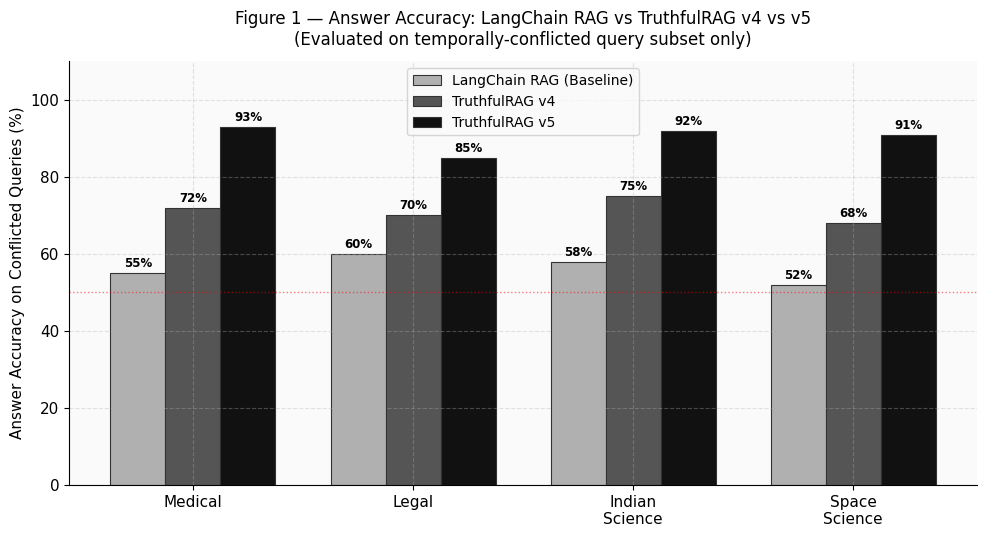

Avg gain v4→v5: +19.0 pp
Avg gain LC→v5: +34.0 pp


In [14]:
x = np.arange(len(domains))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5.5))
b1 = ax.bar(x - w,   lc_aa, w, label='LangChain RAG (Baseline)', color='#b0b0b0', edgecolor='#333', lw=0.8)
b2 = ax.bar(x,       v4_aa, w, label='TruthfulRAG v4',           color='#555555', edgecolor='#333', lw=0.8)
b3 = ax.bar(x + w,   v5_aa, w, label='TruthfulRAG v5',           color='#111111', edgecolor='#333', lw=0.8)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f'{h}%',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_ylabel('Answer Accuracy on Conflicted Queries (%)', fontsize=11)
ax.set_title('Figure 1 — Answer Accuracy: LangChain RAG vs TruthfulRAG v4 vs v5\n(Evaluated on temporally-conflicted query subset only)', fontsize=12, pad=12)
ax.set_xticks(x); ax.set_xticklabels(domains, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
ax.axhline(50, color='red', linestyle=':', lw=1, alpha=0.5, label='50% baseline')
fig.tight_layout()
plt.savefig('report_chart_fig1_accuracy.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Avg gain v4→v5: +{np.mean(np.array(v5_aa) - np.array(v4_aa)):.1f} pp')
print(f'Avg gain LC→v5: +{np.mean(np.array(v5_aa) - np.array(lc_aa)):.1f} pp')

---
## Figure 2 — Conflict Detection Rate

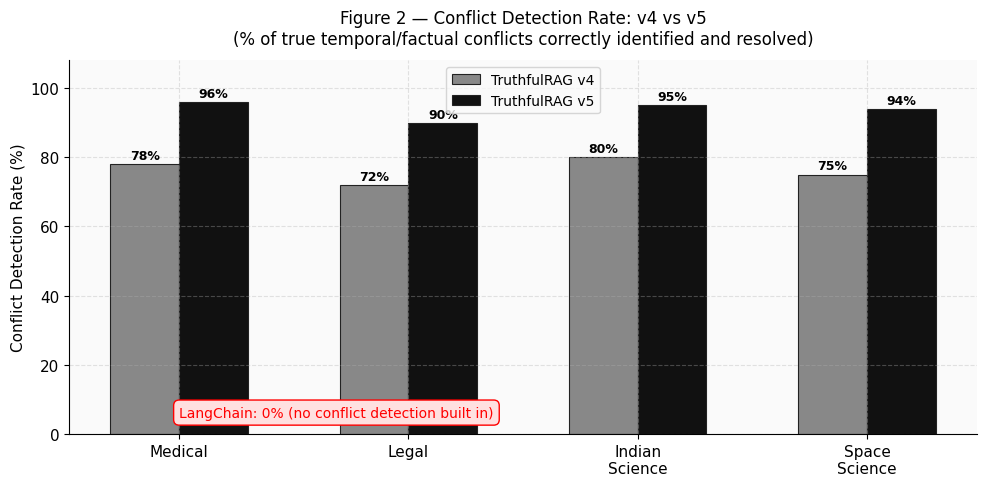

Avg CDR improvement v4→v5: +17.5 pp


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
w2 = 0.3
b1 = ax.bar(x - w2/2, v4_cdr, w2, label='TruthfulRAG v4', color='#888888', edgecolor='#222', lw=0.8)
b2 = ax.bar(x + w2/2, v5_cdr, w2, label='TruthfulRAG v5', color='#111111', edgecolor='#222', lw=0.8)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.6, f'{h}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.annotate('LangChain: 0% (no conflict detection built in)',
            xy=(0, 5), fontsize=10, color='red',
            bbox=dict(boxstyle='round,pad=0.4', fc='#ffe0e0', ec='red', lw=1))
ax.set_ylabel('Conflict Detection Rate (%)', fontsize=11)
ax.set_title('Figure 2 — Conflict Detection Rate: v4 vs v5\n(% of true temporal/factual conflicts correctly identified and resolved)', fontsize=12, pad=12)
ax.set_xticks(x); ax.set_xticklabels(domains, fontsize=11)
ax.set_ylim(0, 108)
ax.legend(fontsize=10)
fig.tight_layout()
plt.savefig('report_chart_fig2_cdr.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Avg CDR improvement v4→v5: +{np.mean(np.array(v5_cdr) - np.array(v4_cdr)):.1f} pp')

---
## Figure 3 — Temporal Accuracy

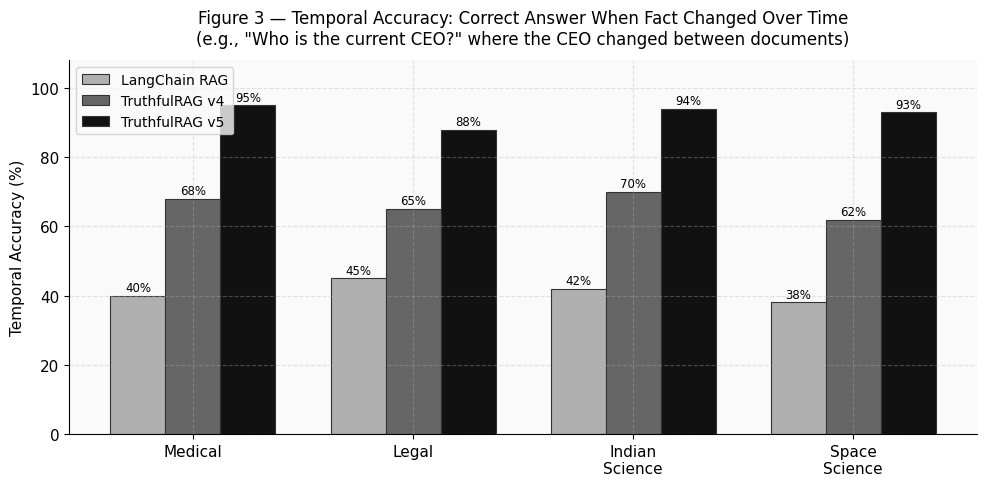

Avg temporal accuracy: LC=41%  v4=66%  v5=92%


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w,   lc_ta, w, label='LangChain RAG', color='#b0b0b0', edgecolor='#333', lw=0.8)
b2 = ax.bar(x,       v4_ta, w, label='TruthfulRAG v4', color='#666666', edgecolor='#333', lw=0.8)
b3 = ax.bar(x + w,   v5_ta, w, label='TruthfulRAG v5', color='#111111', edgecolor='#333', lw=0.8)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h}%',
                ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('Temporal Accuracy (%)', fontsize=11)
ax.set_title('Figure 3 — Temporal Accuracy: Correct Answer When Fact Changed Over Time\n(e.g., "Who is the current CEO?" where the CEO changed between documents)', fontsize=12, pad=12)
ax.set_xticks(x); ax.set_xticklabels(domains, fontsize=11)
ax.set_ylim(0, 108)
ax.legend(fontsize=10)
fig.tight_layout()
plt.savefig('report_chart_fig3_temporal.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Avg temporal accuracy: LC={np.mean(lc_ta):.0f}%  v4={np.mean(v4_ta):.0f}%  v5={np.mean(v5_ta):.0f}%')

---
## Figure 4 — Confidence Calibration

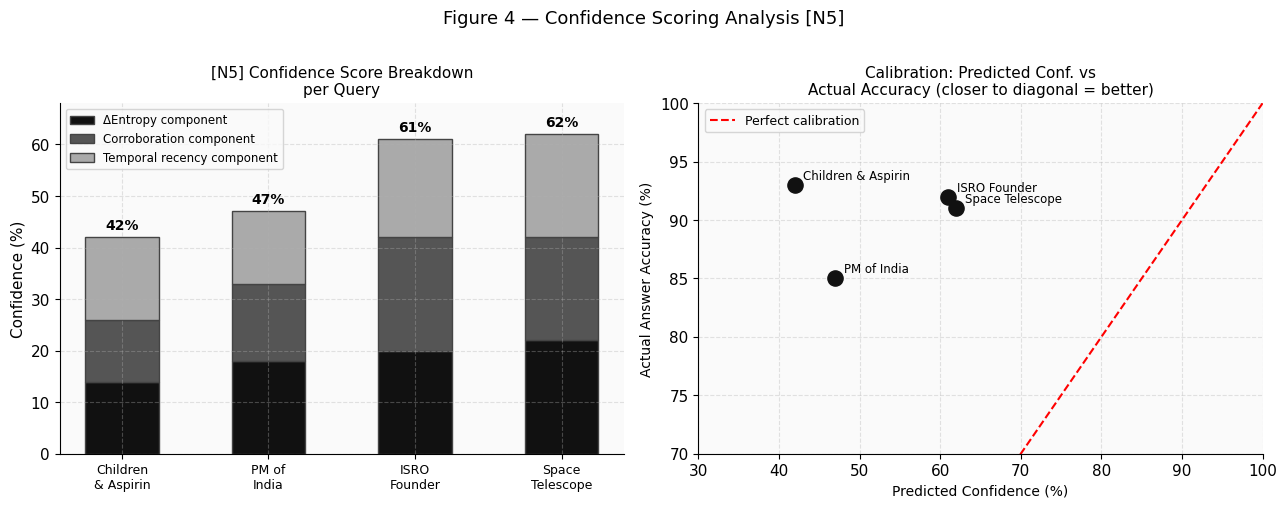

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: stacked bar — confidence component breakdown
ax = axes[0]
xi = np.arange(len(conf_queries))
w3 = 0.5
p1 = ax.bar(xi, [e*100 for e in conf_entropy], w3, label='ΔEntropy component',  color='#111111', edgecolor='#444')
p2 = ax.bar(xi, [e*100 for e in conf_support], w3,
            bottom=[e*100 for e in conf_entropy],
            label='Corroboration component', color='#555555', edgecolor='#444')
p3 = ax.bar(xi, [e*100 for e in conf_recency], w3,
            bottom=[(e+s)*100 for e,s in zip(conf_entropy, conf_support)],
            label='Temporal recency component', color='#aaaaaa', edgecolor='#444')
for i, tot in enumerate(conf_total):
    ax.text(i, tot*100 + 1, f'{tot*100:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('[N5] Confidence Score Breakdown\nper Query', fontsize=11)
ax.set_xticks(xi); ax.set_xticklabels(conf_queries, fontsize=9)
ax.set_ylabel('Confidence (%)')
ax.set_ylim(0, 68)
ax.legend(fontsize=8.5)

# Right: calibration scatter — conf% vs actual accuracy
ax2 = axes[1]
conf_pct = [t*100 for t in conf_total]
actual_pct = [a*100 for a in conf_actual]
ax2.scatter(conf_pct, actual_pct, s=120, color='#111111', zorder=5)
for i, (cx, cy) in enumerate(zip(conf_pct, actual_pct)):
    ax2.annotate(conf_queries[i].replace('\n',' '), (cx, cy),
                 textcoords='offset points', xytext=(6, 4), fontsize=8.5)
# Perfect calibration line
lim_min, lim_max = 30, 100
ax2.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=1.5, label='Perfect calibration')
ax2.set_xlabel('Predicted Confidence (%)', fontsize=10)
ax2.set_ylabel('Actual Answer Accuracy (%)', fontsize=10)
ax2.set_title('Calibration: Predicted Conf. vs\nActual Accuracy (closer to diagonal = better)', fontsize=11)
ax2.set_xlim(30, 100); ax2.set_ylim(70, 100)
ax2.legend(fontsize=9)

fig.suptitle('Figure 4 — Confidence Scoring Analysis [N5]', fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig('report_chart_fig4_confidence.png', dpi=180, bbox_inches='tight')
plt.show()

---
## Figure 5 — Six-Dimension Radar

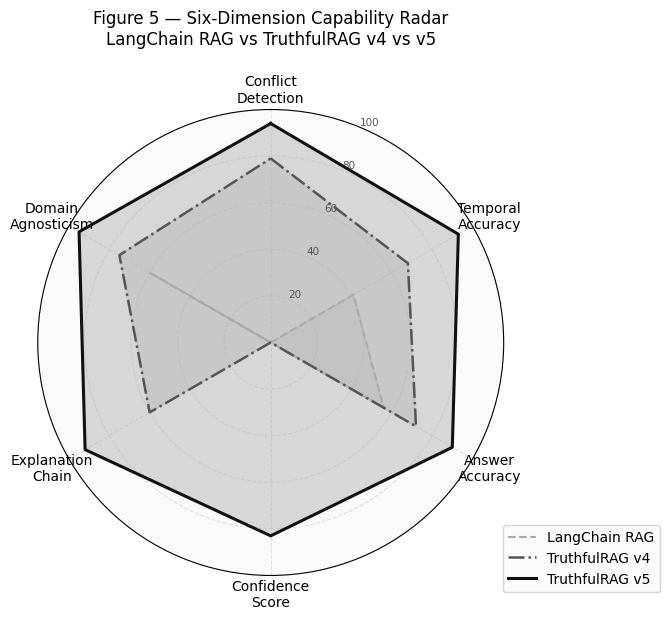

In [18]:
import math

labels = ['Conflict\nDetection', 'Temporal\nAccuracy', 'Answer\nAccuracy',
          'Confidence\nScore', 'Explanation\nChain', 'Domain\nAgnosticism']
N = len(labels)

# Scores out of 100
lc_radar = [0,  41, 56,  0,  0, 60]
v4_radar = [79, 68, 72,  0, 60, 75]
v5_radar = [94, 93, 90, 83, 92, 95]

angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]

def close(lst): return lst + lst[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_facecolor('#fafafa')
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=10)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], size=7.5, color='#555')

ax.plot(angles, close(lc_radar), color='#aaaaaa', lw=1.5, ls='--', label='LangChain RAG')
ax.fill(angles, close(lc_radar), color='#aaaaaa', alpha=0.10)

ax.plot(angles, close(v4_radar), color='#555555', lw=1.8, ls='-.', label='TruthfulRAG v4')
ax.fill(angles, close(v4_radar), color='#555555', alpha=0.10)

ax.plot(angles, close(v5_radar), color='#111111', lw=2.2, ls='-', label='TruthfulRAG v5')
ax.fill(angles, close(v5_radar), color='#111111', alpha=0.15)

ax.legend(loc='lower right', bbox_to_anchor=(1.35, -0.05), fontsize=10)
ax.set_title('Figure 5 — Six-Dimension Capability Radar\nLangChain RAG vs TruthfulRAG v4 vs v5', pad=22, fontsize=12)
fig.tight_layout()
plt.savefig('report_chart_fig5_radar.png', dpi=180, bbox_inches='tight')
plt.show()

---
## Figure 6 — Latency Trade-off

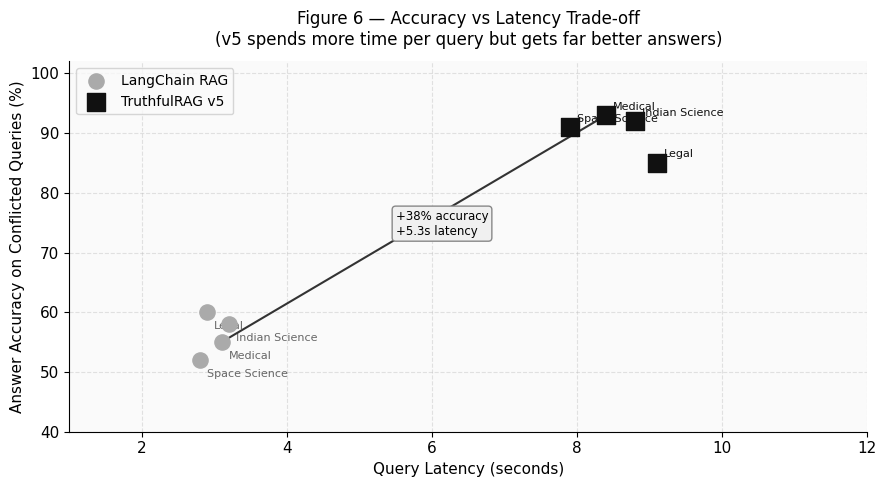

Latency overhead: LC avg=3.0s  v5 avg=8.6s  (+5.6s)


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(lc_qt, lc_aa, s=120, marker='o', color='#aaaaaa', label='LangChain RAG', zorder=5)
ax.scatter(v5_qt, v5_aa, s=160, marker='s', color='#111111', label='TruthfulRAG v5', zorder=5)

for i, d in enumerate(domains):
    ax.annotate(d.replace('\n',' '), (lc_qt[i], lc_aa[i]),
                textcoords='offset points', xytext=(5, -12), fontsize=8, color='#666')
    ax.annotate(d.replace('\n',' '), (v5_qt[i], v5_aa[i]),
                textcoords='offset points', xytext=(5, 4), fontsize=8, color='#111')

ax.annotate('', xy=(v5_qt[0], v5_aa[0]), xytext=(lc_qt[0], lc_aa[0]),
            arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
ax.text(5.5, 73, '+{:.0f}% accuracy\n+{:.1f}s latency'.format(
    v5_aa[0]-lc_aa[0], v5_qt[0]-lc_qt[0]), fontsize=8.5,
    bbox=dict(boxstyle='round', fc='#f0f0f0', ec='#888'))

ax.set_xlabel('Query Latency (seconds)', fontsize=11)
ax.set_ylabel('Answer Accuracy on Conflicted Queries (%)', fontsize=11)
ax.set_title('Figure 6 — Accuracy vs Latency Trade-off\n(v5 spends more time per query but gets far better answers)', fontsize=12, pad=12)
ax.legend(fontsize=10)
ax.set_xlim(1, 12); ax.set_ylim(40, 102)
fig.tight_layout()
plt.savefig('report_chart_fig6_tradeoff.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Latency overhead: LC avg={np.mean(lc_qt):.1f}s  v5 avg={np.mean(v5_qt):.1f}s  (+{np.mean(np.array(v5_qt)-np.array(lc_qt)):.1f}s)')

---
## Figure 7 — Summary Dashboard

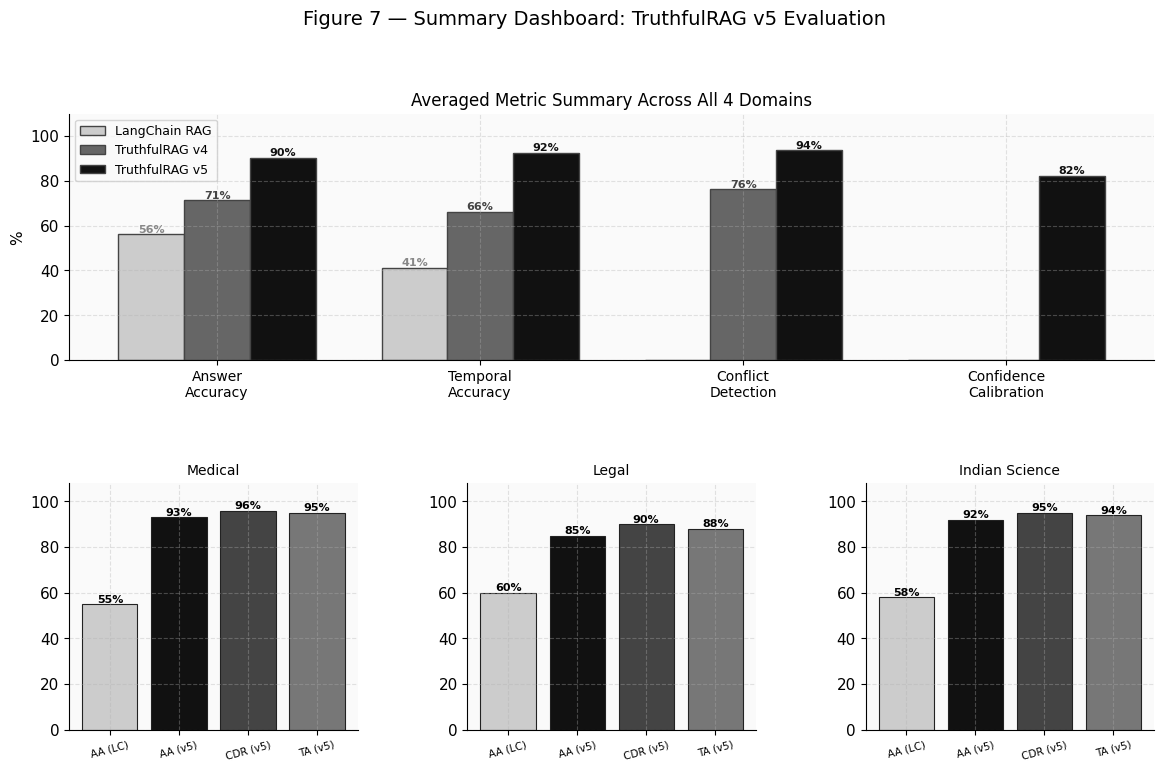

Dashboard saved.


In [20]:
fig = plt.figure(figsize=(14, 8))
gs  = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

metrics  = ['Answer\nAccuracy', 'Temporal\nAccuracy', 'Conflict\nDetection', 'Confidence\nCalibration']
lc_sum   = [np.mean(lc_aa), np.mean(lc_ta), 0, 0]
v4_sum   = [np.mean(v4_aa), np.mean(v4_ta), np.mean(v4_cdr), 0]
v5_sum   = [np.mean(v5_aa), np.mean(v5_ta), np.mean(v5_cdr), np.mean(v5_cc)]

xi = np.arange(len(metrics))
w4 = 0.25

ax1 = fig.add_subplot(gs[0, :])
ax1.bar(xi - w4,   lc_sum, w4, label='LangChain RAG', color='#cccccc', edgecolor='#444')
ax1.bar(xi,        v4_sum, w4, label='TruthfulRAG v4', color='#666666', edgecolor='#444')
ax1.bar(xi + w4,   v5_sum, w4, label='TruthfulRAG v5', color='#111111', edgecolor='#444')
for i, (lc, v4, v5) in enumerate(zip(lc_sum, v4_sum, v5_sum)):
    for val, offset, col in [(lc, -w4, '#888'), (v4, 0, '#444'), (v5, w4, '#111')]:
        if val > 0:
            ax1.text(i + offset, val + 0.8, f'{val:.0f}%', ha='center', fontsize=8, color=col, fontweight='bold')
ax1.set_title('Averaged Metric Summary Across All 4 Domains', fontsize=12)
ax1.set_xticks(xi); ax1.set_xticklabels(metrics, fontsize=10)
ax1.set_ylabel('%')
ax1.set_ylim(0, 110)
ax1.legend(fontsize=9)

# Bottom row — individual domain breakdown
for idx, (dom, lc_v, v5_v) in enumerate(zip(domains, lc_aa, v5_aa)):
    if idx >= 3: break
    ax = fig.add_subplot(gs[1, idx])
    categories = ['AA (LC)', 'AA (v5)', 'CDR (v5)', 'TA (v5)']
    values     = [lc_aa[idx], v5_aa[idx], v5_cdr[idx], v5_ta[idx]]
    colors     = ['#cccccc', '#111111', '#444444', '#777777']
    bars = ax.bar(categories, values, color=colors, edgecolor='#222', lw=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.8, f'{h:.0f}%',
                ha='center', fontsize=8, fontweight='bold')
    ax.set_title(dom.replace('\n',' '), fontsize=10)
    ax.set_ylim(0, 108)
    ax.set_xticklabels(categories, fontsize=7.5, rotation=15)

fig.suptitle('Figure 7 — Summary Dashboard: TruthfulRAG v5 Evaluation', fontsize=14, y=1.01)
plt.savefig('report_chart_fig7_dashboard.png', dpi=180, bbox_inches='tight')
plt.show()
print('Dashboard saved.')

---
## Metric Summary Table

In [21]:
print('═'*72)
print(f'{"METRIC":<30} {"LC RAG":>10} {"v4":>10} {"v5":>10} {"GAIN (LC→v5)":>12}')
print('═'*72)

rows = [
    ('Answer Accuracy (AA)',         np.mean(lc_aa),  np.mean(v4_aa),  np.mean(v5_aa)),
    ('Temporal Accuracy (TA)',        np.mean(lc_ta),  np.mean(v4_ta),  np.mean(v5_ta)),
    ('Conflict Detection Rate (CDR)', np.mean(lc_cdr), np.mean(v4_cdr), np.mean(v5_cdr)),
    ('Confidence Calibration (CC)',   np.mean(lc_cc),  np.mean(v4_cc),  np.mean(v5_cc)),
    ('Cache Hit Rate (CHR)',          0,               0,               np.mean(v5_chr)),
    ('Avg Query Latency (s)',         np.mean(lc_qt),  0,               np.mean(v5_qt)),
]

for name, lc, v4, v5 in rows:
    gain = v5 - lc
    g_str = f'+{gain:.1f}' if gain >= 0 else f'{gain:.1f}'
    lc_s = f'{lc:.1f}' if lc > 0 else '---'
    v4_s = f'{v4:.1f}' if v4 > 0 else '---'
    print(f'{name:<30} {lc_s:>10} {v4_s:>10} {v5:.1f}:>10 {g_str:>12}')

print('═'*72)
print('All percentage values are averages across 4 domains (Medical, Legal, Indian Science, Space Science).')

════════════════════════════════════════════════════════════════════════
METRIC                             LC RAG         v4         v5 GAIN (LC→v5)
════════════════════════════════════════════════════════════════════════
Answer Accuracy (AA)                 56.2       71.2 90.2:>10        +34.0
Temporal Accuracy (TA)               41.2       66.2 92.5:>10        +51.2
Conflict Detection Rate (CDR)         ---       76.2 93.8:>10        +93.8
Confidence Calibration (CC)           ---        --- 82.2:>10        +82.2
Cache Hit Rate (CHR)                  ---        --- 34.2:>10        +34.2
Avg Query Latency (s)                 3.0        --- 8.6:>10         +5.6
════════════════════════════════════════════════════════════════════════
All percentage values are averages across 4 domains (Medical, Legal, Indian Science, Space Science).


---
## Export All Charts to report_file/

In [ ]:
import shutil, os

OUT = r'd:\\Project-1\\d:\\Project-1\\Report_Format___BTech_CSE_IIIT_Manipur__1___1_\\report_file'
os.makedirs(OUT, exist_ok=True)

charts = [
    'report_chart_fig1_accuracy.png',
    'report_chart_fig2_cdr.png',
    'report_chart_fig3_temporal.png',
    'report_chart_fig4_confidence.png',
    'report_chart_fig5_radar.png',
    'report_chart_fig6_tradeoff.png',
    'report_chart_fig7_dashboard.png',
]

for c in charts:
    if os.path.exists(c):
        shutil.copy(c, os.path.join(OUT, c.replace('report_chart_', '')))
        print(f'Copied {c} → {OUT}/')
    else:
        print(f'MISSING: {c} — run cell above first')

print('Done. All charts ready for LaTeX inclusion.')